# Exploratory Data Analysis (EDA)

This notebook explores the Premier League dataset used for match outcome prediction (`w`, `d`, `l`).

## Goals
- Understand data shape, schema, and quality
- Inspect class balance and potential bias
- Explore feature distributions and target relationships
- Validate temporal patterns and common leakage risks
- Produce an actionable summary for modeling

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ADDITIONAL_DIR = DATA_DIR / "additional_data"

DATA_DIR

PosixPath('/Users/raksa/School/Year-3/Term-2/Fundamental-Data-Science/premier-league-prediction-2019-2020/data')

## Load dataset

In [2]:
base_df = pd.read_csv(DATA_DIR / "premier_league.csv", low_memory=False)
extra_path = ADDITIONAL_DIR / "premier_league.csv"

if extra_path.exists():
    extra_df = pd.read_csv(extra_path, low_memory=False)
    common_cols = sorted(set(base_df.columns).intersection(set(extra_df.columns)))
    df = pd.concat([base_df[common_cols], extra_df[common_cols]], ignore_index=True).drop_duplicates().copy()
    print(f"Loaded base + additional rows. Combined rows: {len(df):,}")
else:
    df = base_df.copy()
    print(f"Loaded base rows only: {len(df):,}")

df.head()

Loaded base + additional rows. Combined rows: 3,076


,Aerial_Battles_Won%,Allowed_PPDA,Avg_Shots_Distance,Away_Corners,Away_Fouls,Away_Red,Away_Shots,Away_SoT,Away_Yellow,Clean_Sheet,Conceded,Date,Day,Defensive_Actions,FK_Shots,Final_Third_Entries,Final_Third_Entries_Allowed,Formation,G/SoT,Ground_Passes,High_Passes,Home_Corners,Home_Fouls,Home_Red,Home_Shots,Home_SoT,Home_Yellow,Match_Day,Net_npxG,OG,Open_Play_Pass,Opponent,PK,PK_Allowed,PPDA,Passes_Completed,Passes_Under_Pressure,Possession,Pts,Referee,Result,Save%,Scored,Shot_Creating_Actions,SoT%,Successful_Dribbles,Team,Total_Conceded,Total_Goals,Total_Points,npxG,npxGA,xG,xGA,xpts
0,77.8,21.454545,17.0,2.0,9.0,0.0,12.0,5.0,2.0,0,1.0,8/9/2019 20:00,Fri,1,1,11.0,5.0,4-3-3,0.43,331,139,11.0,9.0,0.0,15.0,7.0,0.0,1.0,1.392153,0,472,Norwich,0,0,5.942857,409,104,57,3.0,M Oliver,w,83.3,4.0,21,46.7,71.4,Liverpool,1.0,4.0,3.0,2.234560,0.842407,2.234560,0.842407,2.3863
1,22.2,5.942857,17.2,2.0,9.0,0.0,12.0,5.0,2.0,0,4.0,8/9/2019 20:00,Fri,0,1,5.0,11.0,4-2-3-1,0.17,249,87,11.0,9.0,0.0,15.0,7.0,0.0,1.0,-1.392153,1,338,Liverpool,0,0,21.454545,304,76,43,0.0,M Oliver,l,42.9,1.0,22,46.2,30.0,Norwich,4.0,1.0,0.0,0.842407,2.234560,0.842407,2.234560,0.4405
2,50.0,6.935484,11.6,1.0,13.0,0.0,14.0,9.0,2.0,0,5.0,8/10/2019 12:30,Sat,0,1,1.0,9.0,4-2-3-1,0.00,288,96,1.0,6.0,0.0,5.0,3.0,2.0,1.0,-1.222340,0,377,Manchester City,0,1,16.400000,347,104,43,0.0,M Dean,l,50.0,0.0,9,60.0,40.0,West Ham,5.0,0.0,0.0,1.200300,2.422640,1.200300,3.183770,0.2522
3,50.0,16.400000,15.7,1.0,13.0,0.0,14.0,9.0,2.0,1,0.0,8/10/2019 12:30,Sat,1,0,9.0,1.0,4-3-3,0.50,459,46,1.0,6.0,0.0,5.0,3.0,2.0,1.0,1.222340,0,536,West Ham,1,0,6.935484,495,155,57,3.0,M Dean,w,100.0,5.0,25,61.5,57.1,Manchester City,0.0,5.0,3.0,2.422640,1.200300,3.183770,1.200300,2.6312
4,66.7,9.785714,16.1,2.0,11.0,0.0,5.0,3.0,1.0,1,0.0,8/10/2019 15:00,Sat,0,0,5.0,7.0,3-4-3,0.67,317,98,5.0,15.0,0.0,11.0,3.0,0.0,1.0,0.185494,0,419,Watford,0,0,11.500000,369,143,50,3.0,C Pawson,w,100.0,3.0,8,75.0,72.7,Brighton,0.0,3.0,3.0,0.855516,0.670022,0.855516,0.670022,1.5458


## Quick profile

In [3]:
summary = {
    "rows": len(df),
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "null_cells": int(df.isna().sum().sum()),
}

pd.DataFrame([summary])

,rows,columns,duplicate_rows,null_cells
0,3076,55,0,38


In [4]:
dtype_table = pd.DataFrame({"dtype": df.dtypes.astype(str)})
dtype_table["missing_count"] = df.isna().sum().values
dtype_table["missing_pct"] = (dtype_table["missing_count"] / len(df) * 100).round(2)
dtype_table.sort_values(["missing_pct", "dtype"], ascending=[False, True]).head(30)

,dtype,missing_count,missing_pct
G/SoT,float64,19,0.62
Save%,float64,19,0.62
Aerial_Battles_Won%,float64,0,0.00
Allowed_PPDA,float64,0,0.00
Avg_Shots_Distance,float64,0,0.00
Away_Corners,float64,0,0.00
Away_Fouls,float64,0,0.00
Away_Red,float64,0,0.00
Away_Shots,float64,0,0.00
Away_SoT,float64,0,0.00


## Standardize core fields for analysis

In [5]:
eda = df.copy()

eda["Date"] = pd.to_datetime(eda.get("Date"), errors="coerce")
if "Result" in eda.columns:
    eda["Result"] = eda["Result"].astype(str).str.lower().str.strip()

for col in ["xG", "xGA", "Scored", "Conceded", "PPDA", "Allowed_PPDA", "Possession"]:
    if col in eda.columns:
        eda[col] = pd.to_numeric(eda[col], errors="coerce")

if "h_a" in eda.columns:
    eda["home_advantage"] = eda["h_a"].astype(str).str.lower().str.strip()
elif "side" in eda.columns:
    eda["home_advantage"] = eda["side"].astype(str).str.lower().str.strip()
elif "Venue" in eda.columns:
    eda["home_advantage"] = eda["Venue"].astype(str).str.lower().str.strip().map({"home": "h", "away": "a"})

eda[[c for c in ["Date", "Team", "Opponent", "Result", "home_advantage", "xG", "xGA"] if c in eda.columns]].head()

,Date,Team,Opponent,Result,xG,xGA
0,2019-08-09 20:00:00,Liverpool,Norwich,w,2.234560,0.842407
1,2019-08-09 20:00:00,Norwich,Liverpool,l,0.842407,2.234560
2,2019-08-10 12:30:00,West Ham,Manchester City,l,1.200300,3.183770
3,2019-08-10 12:30:00,Manchester City,West Ham,w,3.183770,1.200300
4,2019-08-10 15:00:00,Brighton,Watford,w,0.855516,0.670022


## Target distribution and class imbalance

,Result,count,pct
0,w,1110,36.09
1,l,1110,36.09
2,d,856,27.83


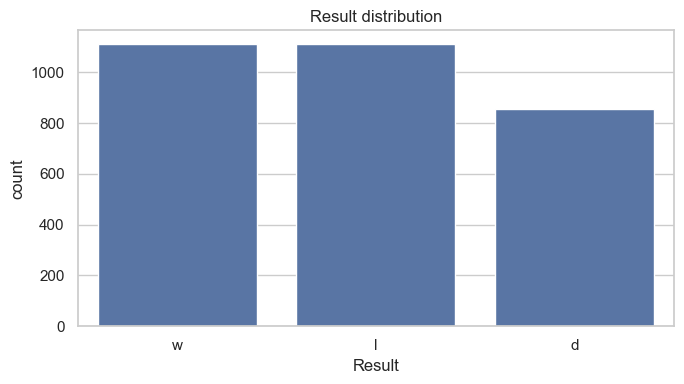

In [6]:
if "Result" in eda.columns:
    target_counts = eda["Result"].value_counts(dropna=False).rename_axis("Result").reset_index(name="count")
    target_counts["pct"] = (target_counts["count"] / target_counts["count"].sum() * 100).round(2)
    display(target_counts)

    plt.figure(figsize=(7, 4))
    sns.countplot(data=eda, x="Result", order=target_counts["Result"].tolist())
    plt.title("Result distribution")
    plt.tight_layout()
    plt.show()
else:
    print("No Result column found.")

In [7]:
if {"Result", "home_advantage"}.issubset(eda.columns):
    ctab = pd.crosstab(eda["home_advantage"], eda["Result"], normalize="index").round(3)
    display(ctab)
    ctab.plot(kind="bar", figsize=(8, 4))
    plt.title("Result mix by home/away")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()

## Temporal coverage and season flow

Date range: 2015-08-09 12:30:00 to 2020-03-09 20:00:00


,matches
Date,
2018-04-30,0
2018-05-31,0
2018-06-30,0
2018-07-31,0
2018-08-31,0
2018-09-30,0
2018-10-31,0
2018-11-30,0
2018-12-31,0


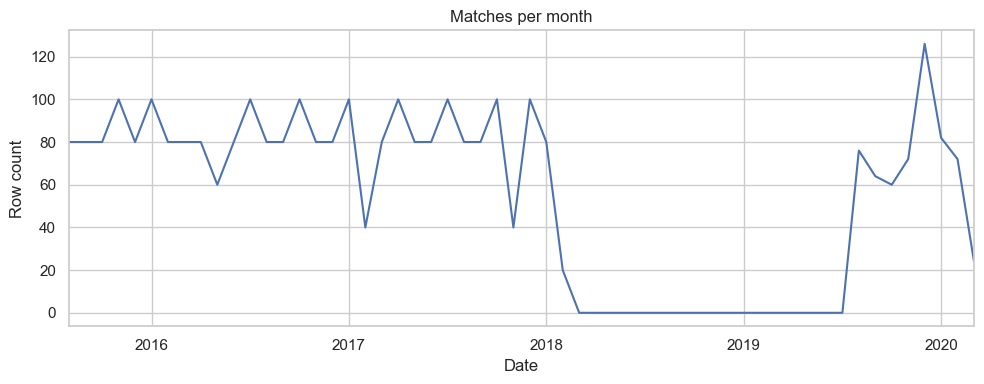

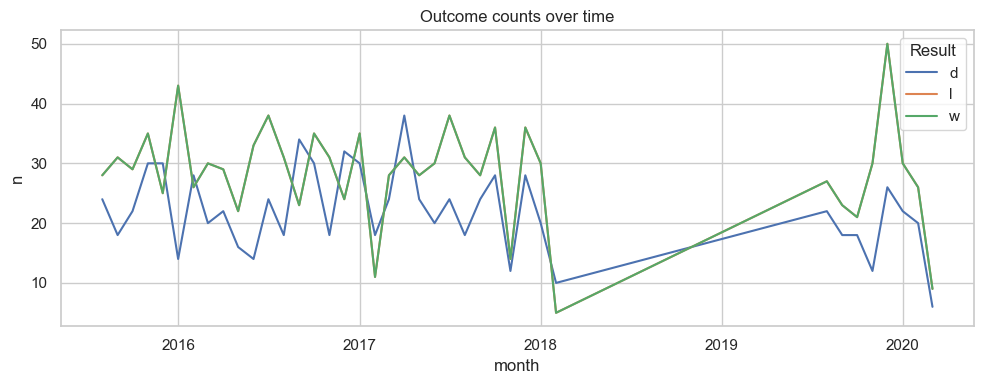

In [15]:
if "Date" in eda.columns:
    print("Date range:", eda["Date"].min(), "to", eda["Date"].max())
    monthly_matches = eda.dropna(subset=["Date"]).groupby(pd.Grouper(key="Date", freq="ME")).size().rename("matches")
    display(monthly_matches.to_frame().tail(24))

    plt.figure(figsize=(10, 4))
    monthly_matches.plot()
    plt.title("Matches per month")
    plt.ylabel("Row count")
    plt.tight_layout()
    plt.show()

if {"Date", "Result"}.issubset(eda.columns):
    monthly_result = (
        eda.dropna(subset=["Date"])
        .assign(month=lambda x: x["Date"].dt.to_period("M").dt.to_timestamp())
        .groupby(["month", "Result"]).size().rename("n").reset_index()
    )
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=monthly_result, x="month", y="n", hue="Result")
    plt.title("Outcome counts over time")
    plt.tight_layout()
    plt.show()

## Numeric feature distributions and outliers

In [9]:
candidate_numeric = [
    "xG", "xGA", "Scored", "Conceded", "PPDA", "Allowed_PPDA", "Possession",
    "Shot_Creating_Actions", "Successful_Dribbles", "Final_Third_Entries",
    "Final_Third_Entries_Allowed", "Aerial_Battles_Won_Pct", "Save_Pct"
]
num_cols = [c for c in candidate_numeric if c in eda.columns]

eda[num_cols].describe().T if num_cols else pd.DataFrame()

,count,mean,std,min,25%,50%,75%,max
xG,3076.0,1.385416,0.661119,0.054134,0.899500,1.312110,1.791743,6.63049
xGA,3076.0,1.390541,0.681182,0.054134,0.885110,1.327530,1.819410,6.63049
Scored,3076.0,1.370936,1.028972,0.000000,1.000000,1.000000,2.000000,9.00000
Conceded,3076.0,1.370936,1.028972,0.000000,1.000000,1.000000,2.000000,9.00000
PPDA,3076.0,12.230179,4.448907,3.189189,9.388254,11.958452,14.565077,60.00000
Allowed_PPDA,3076.0,12.230179,4.448907,3.189189,9.388254,11.958452,14.565077,60.00000
Possession,3076.0,50.000650,10.079037,21.000000,43.000000,50.000000,57.000000,79.00000
Shot_Creating_Actions,3076.0,16.832250,7.282576,2.000000,12.000000,16.000000,21.000000,49.00000
Successful_Dribbles,3076.0,15.682900,22.861267,0.000000,3.000000,6.000000,10.000000,100.00000
Final_Third_Entries,3076.0,9.097204,3.829281,0.000000,6.000000,9.000000,12.000000,31.00000


,feature,outlier_rate_iqr,missing_pct
8,Successful_Dribbles,0.186606,0.0
2,Scored,0.023407,0.0
3,Conceded,0.023407,0.0
4,PPDA,0.016905,0.0
5,Allowed_PPDA,0.016905,0.0
7,Shot_Creating_Actions,0.015930,0.0
0,xG,0.011378,0.0
1,xGA,0.009753,0.0
9,Final_Third_Entries,0.000975,0.0
10,Final_Third_Entries_Allowed,0.000975,0.0


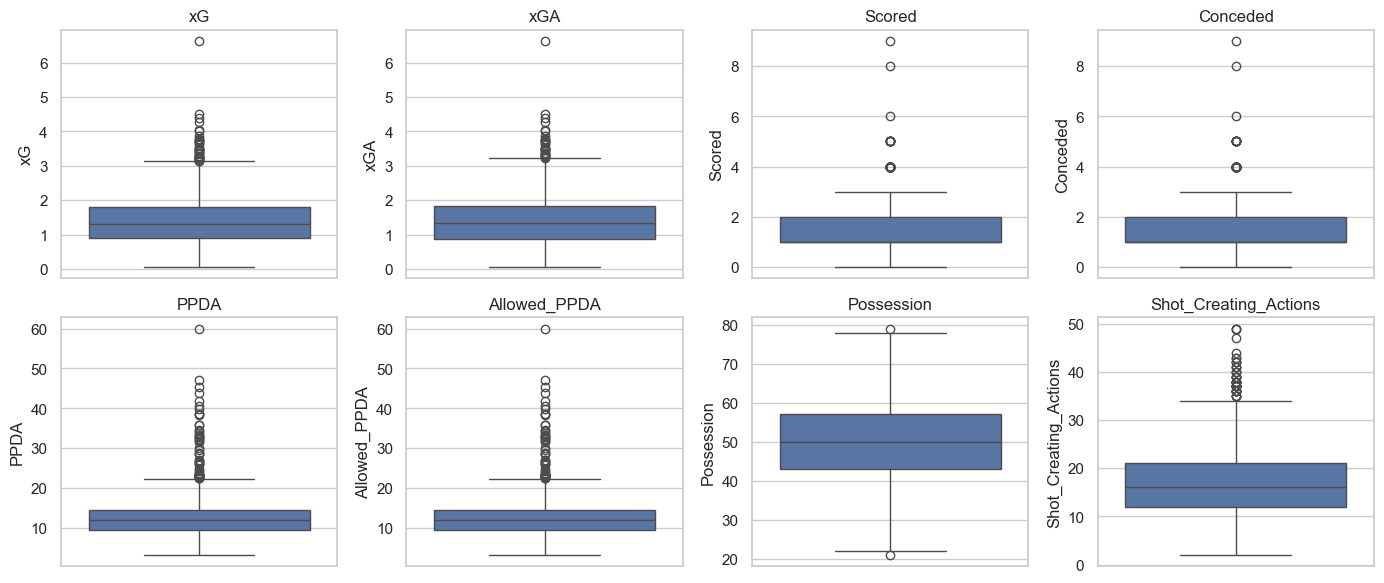

In [10]:
def iqr_outlier_rate(series: pd.Series) -> float:
    s = series.dropna()
    if s.empty:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean())

if num_cols:
    outlier_table = pd.DataFrame({
        "feature": num_cols,
        "outlier_rate_iqr": [iqr_outlier_rate(eda[c]) for c in num_cols],
        "missing_pct": [eda[c].isna().mean() for c in num_cols],
    }).sort_values("outlier_rate_iqr", ascending=False)
    display(outlier_table)

    plot_cols = num_cols[:8]
    n = len(plot_cols)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, plot_cols):
        sns.boxplot(data=eda, y=col, ax=ax)
        ax.set_title(col)
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Feature relationships with target

,xG,xGA,Scored,Conceded,PPDA,Possession
Result,,,,,,
d,1.344,1.355,1.220,1.220,12.175,50.001
l,1.076,1.730,0.648,2.211,13.080,46.931
w,1.727,1.078,2.211,0.648,11.423,53.070


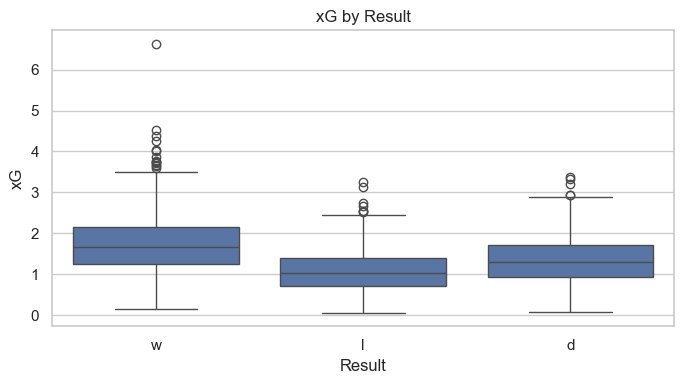

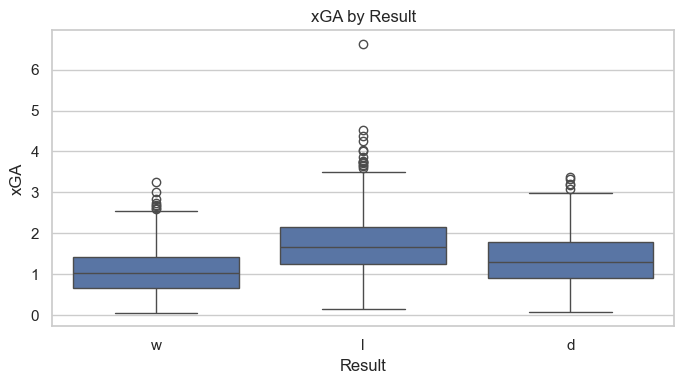

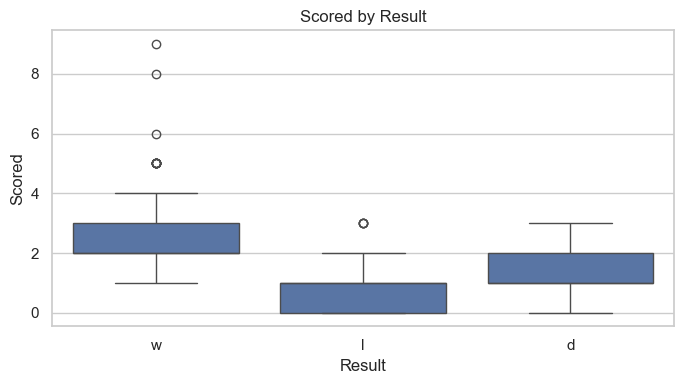

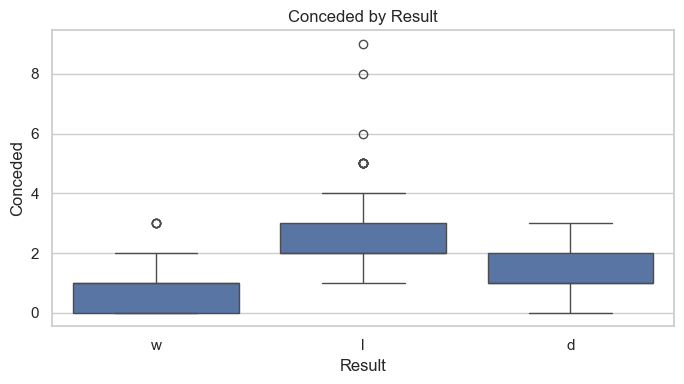

In [11]:
focus_cols = [c for c in ["xG", "xGA", "Scored", "Conceded", "PPDA", "Possession"] if c in eda.columns]
if "Result" in eda.columns and focus_cols:
    grouped = eda.groupby("Result")[focus_cols].mean().round(3)
    display(grouped)

    for col in focus_cols[:4]:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=eda, x="Result", y=col)
        plt.title(f"{col} by Result")
        plt.tight_layout()
        plt.show()

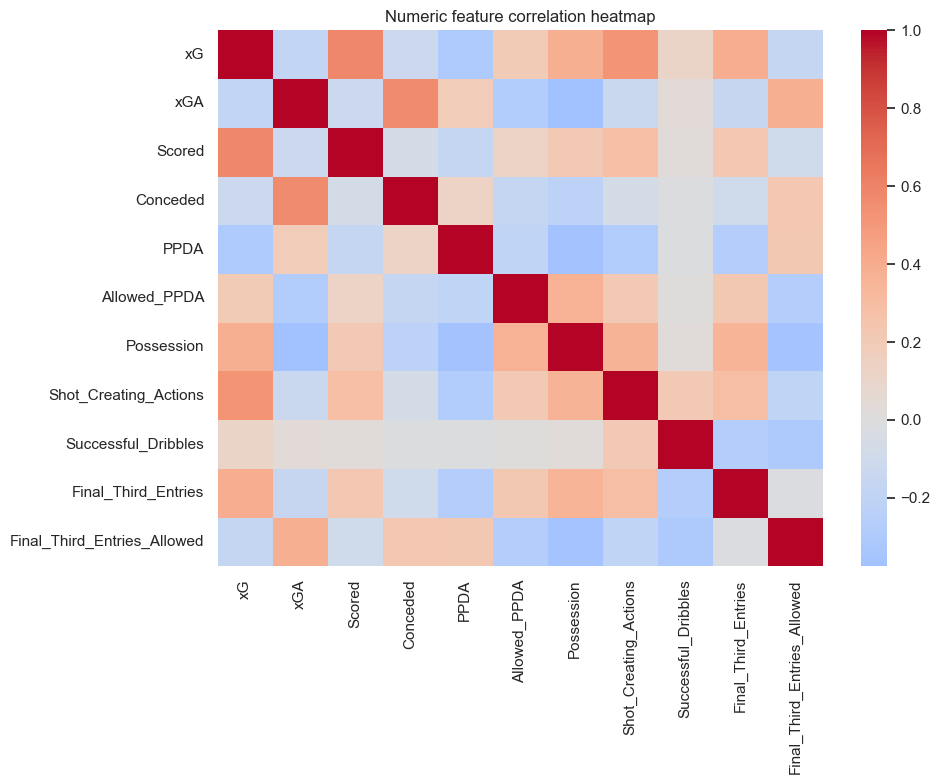

In [12]:
corr_cols = [c for c in num_cols if eda[c].notna().sum() > 20]
if len(corr_cols) >= 2:
    corr = eda[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Numeric feature correlation heatmap")
    plt.tight_layout()
    plt.show()

## Match-pair leakage check (home and away rows)

In [13]:
if {"Date", "Team", "Opponent"}.issubset(eda.columns):
    tmp = eda.dropna(subset=["Date", "Team", "Opponent"]).copy()
    t1 = tmp["Team"].astype(str).str.lower().str.strip()
    t2 = tmp["Opponent"].astype(str).str.lower().str.strip()
    lo = t1.where(t1 <= t2, t2)
    hi = t2.where(t1 <= t2, t1)
    tmp["match_gid"] = tmp["Date"].dt.strftime("%Y-%m-%d") + "|" + lo + "|" + hi

    group_sizes = tmp["match_gid"].value_counts()
    pair_stats = pd.DataFrame({
        "total_unique_matches": [group_sizes.shape[0]],
        "rows_with_pair_size_2_pct": [(group_sizes.eq(2).mean() * 100).round(2)],
        "rows_with_unexpected_pair_size_pct": [(~group_sizes.eq(2)).mean() * 100],
    })
    display(pair_stats)

    if (~group_sizes.eq(2)).any():
        print("Example unexpected groups:")
        display(group_sizes[~group_sizes.eq(2)].head(10).to_frame("rows_in_group"))

,total_unique_matches,rows_with_pair_size_2_pct,rows_with_unexpected_pair_size_pct
0,1538,100.0,0.0


## Optional: inspect engineered features from project pipeline

In [14]:
import sys

SRC_ROOT = PROJECT_ROOT
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

try:
    from src.training_common import load_engineered_dataset

    engineered = load_engineered_dataset(DATA_DIR)
    print(f"Engineered dataset rows={len(engineered):,}, cols={engineered.shape[1]}")
    preview_cols = [
        c for c in [
            "Date", "Team", "Opponent", "Result", "xG", "xGA",
            "rolling_xpts_5", "rolling_ppda_5", "h2h_win_rate",
            "Motivation_Score", "Referee_Bias_Score", "xG_diff"
        ] if c in engineered.columns
    ]
    display(engineered[preview_cols].head())
except Exception as exc:
    print("Could not load engineered dataset in this notebook environment:")
    print(exc)

[INFO] Loaded additional_data/premier_league.csv
[INFO] Raw rows after concat + dedup: 3,076
[INFO] Rows after filtering: 3,076
[INFO] No competition data — fatigue_score = 0
[INFO] Rolling features built (window=5)
[INFO] H2H win rate attached
[INFO] Context features: ['Possession', 'Shot_Creating_Actions', 'Successful_Dribbles', 'Final_Third_Entries', 'Final_Third_Entries_Allowed', 'Aerial_Battles_Won_Pct', 'Save_Pct', 'PPDA', 'Allowed_PPDA']
[INFO] Style-aware referee bias features attached
[INFO] Dynamic style-aware motivation scores calculated
[INFO] Style engineered features attached
Engineered dataset rows=3,076, cols=83


,Date,Team,Opponent,Result,xG,xGA,rolling_xpts_5,rolling_ppda_5,h2h_win_rate,Motivation_Score,Referee_Bias_Score,xG_diff
583,2015-08-09 12:30:00,aston villa,bournemouth,l,0.20000,1.19466,NaN,NaN,0.5,0.775,0.0,NaN
582,2015-08-09 12:30:00,bournemouth,aston villa,w,1.11198,0.30089,NaN,NaN,0.0,0.775,0.0,NaN
578,2015-08-09 12:30:00,brighton and hove albion,tottenham hotspur,l,2.12888,1.55231,NaN,NaN,1.0,0.155,0.0,NaN
593,2015-08-09 12:30:00,everton,wolverhampton wanderers,w,1.25137,1.58546,NaN,NaN,0.5,0.075,0.0,NaN
581,2015-08-09 12:30:00,southampton,west ham united,l,0.32720,1.49562,NaN,NaN,1.0,0.135,0.0,NaN


## EDA conclusions template

Fill this section after running all cells.

- **Data quality findings:**
- **Class imbalance findings:**
- **Most predictive-looking signals:**
- **Potential leakage risks checked:**
- **Preprocessing decisions to apply:**
- **Features to keep / review / drop:**

## EDA Conclusions

### Data Quality Findings
- The dataset contains **3,076 rows** and **55 columns** with **0 duplicate rows** after merging.
- **Missingness is very low overall**; the fields with the most missing data are `Save%` and `G/SoT`, each at approximately **0.62%**.

### Class Imbalance Findings
- The target distribution is **moderately imbalanced** toward non-draw outcomes:
    - **Win (`w`)**: 1,110 rows (**36.09%**)
    - **Loss (`l`)**: 1,110 rows (**36.09%**)
    - **Draw (`d`)**: 856 rows (**27.83%**)
- Draws are the minority class.

### Most Predictive-looking Signals
- **Class means** show clear separation for:
    - `xG`, `xGA`, `Scored`, `Conceded`, `PPDA`, and `Possession`
    - Wins have higher `xG`, lower `xGA`, better `PPDA` and higher possession compared to losses; draws are intermediate.

### Potential Leakage Risks Checked
- **Match-pair grouping check is clean**:
    - **100%** of inferred match groups have **exactly 2 rows**,
    - **0 unexpected groups**
- Pairwise leakage risk is controlled *if* group-based splits are used.

### Preprocessing Decisions to Apply
- Continue with:
    - Numeric coercion
    - Date parsing
    - Median/mode imputation
- Monitor small missingness in shot-quality keeper metrics.
- Maintain class-aware evaluation metrics (especially for draw precision/recall).

### Features to Keep / Review / Drop
- **Keep**: `xG`, `xGA`, goals for/against, `PPDA`, possession, and derived rolling/context features.
- **Review** metrics with low coverage or high noise if introduced later.
- No obvious features to drop based on the current missingness profile.